# M14 · Encoders & Contrastive Training — Hands-on, Step by Tiny Step

**Companion to lesson M14. Written for someone new to ML.**

Where do the embeddings from M11–M13 come from? **Encoders** turn raw text/profiles into
vectors, and **contrastive training** teaches them **which pairs should be close and which
should separate**. This is the bridge from "understands language" to "retrieves the right
creator." This notebook builds the two encoder shapes, the **InfoNCE** contrastive loss with
**temperature**, and the thing that makes or breaks a retrieval encoder: **hard negatives**.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · Encoders & the contrastive loss:** **dual vs cross-encoder** (retrieve vs rerank),
  **InfoNCE + temperature**, train a dual encoder, and the **collapse** failure.
- **Part B · Hard negatives & fine-tuning:** **triplet loss**, **why hard negatives raise the
  gradient**, and a demo where **mining hard negatives improves fine-grained recall**.

We use **PyTorch** + **scikit-learn** + **matplotlib** — all preinstalled in Colab. Run each
cell with **Shift+Enter**.

## Step 1 · Setup + synthetic data

Queries and their matched items share a hidden **topic + individual taste**, so a positive pair
should score high. We reuse this data throughout.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
torch.manual_seed(0)
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
D_raw, T = 24, 100
tcent = rng.normal(0, 1, (T, D_raw)) * 2.0                    # many topic centers
def make(n, seed):
    r = np.random.default_rng(seed)
    tp = r.integers(0, T, n)
    taste = r.normal(0, 1, (n, D_raw)) * 0.7                  # individual taste, shared query<->item
    base = tcent[tp] + taste
    q = base + r.normal(0, 0.35, (n, D_raw)); i = base + r.normal(0, 0.35, (n, D_raw))
    return torch.tensor(q, dtype=torch.float32), torch.tensor(i, dtype=torch.float32), tp
Q, I, tpq = make(6000, 1)
Qte, Ite, tpt = make(1500, 2)
print("data ready:", len(Q), "train pairs,", len(Qte), "test pairs,", T, "topics")

data ready: 6000 train pairs, 1500 test pairs, 100 topics


---
# Part A · Encoders & the contrastive objective

## Step 2 · Dual encoder vs cross-encoder

Two shapes:
- **Dual (bi-) encoder** — embeds query and item **separately**; score = dot product. Item
  vectors can be **precomputed & indexed** → perfect for **first-stage retrieval** (M12/M13).
- **Cross-encoder** — reads the **pair together**, so it can compare exact phrases. **More
  accurate**, but must run **once per pair** → too slow to retrieve from millions; used to
  **rerank** a few hundred candidates.

We train both on match/no-match pairs and compare **pair accuracy (AUC)**.

pair-match AUC on HARD (same-topic) pairs:  dual-encoder 0.626   cross-encoder 0.721
dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.


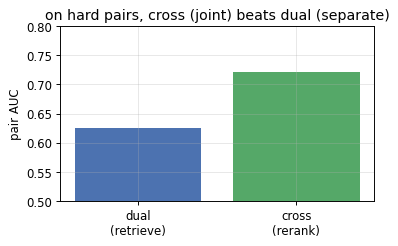

In [5]:
def pairs(Qs, Is, tp, seed):
    r = np.random.default_rng(seed); n = len(Qs); neg = np.zeros(n, dtype=int)
    for j in range(n):                                    # HARD negative: a same-topic different item
        cand = np.where(tp == tp[j])[0]; cand = cand[cand != j]
        neg[j] = r.choice(cand) if len(cand) else j
    qi = torch.cat([Qs, Qs]); ii = torch.cat([Is, Is[neg]])
    y  = torch.cat([torch.ones(n), torch.zeros(n)])
    return qi, ii, y
qtr, itr, ytr = pairs(Q, I, tpq, 1); qte, ite, yte = pairs(Qte, Ite, tpt, 2)
bce = nn.BCEWithLogitsLoss()

class Tower(nn.Module):                                    # one side of a DUAL encoder
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw,32), nn.ReLU(), nn.Linear(32,16))
    def forward(self, x): return self.net(x)
qT, iT = Tower(), Tower(); opt = torch.optim.Adam(list(qT.parameters())+list(iT.parameters()), lr=0.01)
for _ in range(80):
    opt.zero_grad(); bce((qT(qtr)*iT(itr)).sum(1), ytr).backward(); opt.step()
dual_auc = roc_auc_score(yte.numpy(), ((qT(qte)*iT(ite)).sum(1)).detach().numpy())

class Cross(nn.Module):                                    # reads the PAIR jointly
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw*3,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, q, i): return self.net(torch.cat([q, i, q*i], 1)).squeeze(1)
cx = Cross(); opt = torch.optim.Adam(cx.parameters(), lr=0.005)
for _ in range(80):
    opt.zero_grad(); bce(cx(qtr, itr), ytr).backward(); opt.step()
cross_auc = roc_auc_score(yte.numpy(), cx(qte, ite).detach().numpy())

print(f"pair-match AUC on HARD (same-topic) pairs:  dual-encoder {dual_auc:.3f}   cross-encoder {cross_auc:.3f}")
plt.figure(figsize=(4.6,3)); plt.bar(["dual\n(retrieve)","cross\n(rerank)"], [dual_auc, cross_auc], color=[BLUE, GREEN])
plt.ylim(0.5,0.8); plt.ylabel("pair AUC"); plt.title("on hard pairs, cross (joint) beats dual (separate)"); plt.show()
print("dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.")

## Step 3 · The contrastive loss — InfoNCE + temperature

Contrastive training makes the positive **win a softmax** against negatives:
$$\mathcal{L}_i=-\log\frac{\exp(s(q_i,d_i^+)/\tau)}{\sum_j \exp(s(q_i,d_j)/\tau)}$$
`τ` (**temperature**) controls sharpness: **low τ magnifies score gaps**, giving high-scoring
(hard) negatives a bigger gradient. Lesson example: scores `[2.0, 1.0, 0.0]` (positive first).

  tau=1.0 : positive prob 0.665,  loss 0.41
  tau=0.5 : positive prob 0.867,  loss 0.14
  tau=0.1 : positive prob 1.000,  loss 0.00

lower tau -> sharper: the positive's probability shoots up once it's ahead,
and a CLOSE hard negative gets a much larger gradient (more pressure).


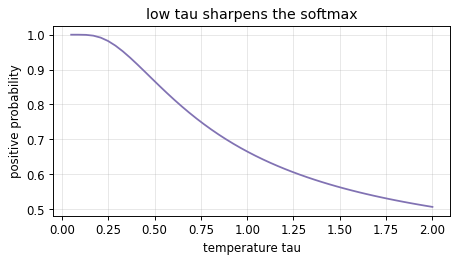

In [7]:
def infonce(scores, tau):
    z = np.array(scores)/tau; z = z - z.max()
    p = np.exp(z)/np.exp(z).sum()
    return p[0], -np.log(p[0])
for tau in [1.0, 0.5, 0.1]:
    p, l = infonce([2.0, 1.0, 0.0], tau)
    print(f"  tau={tau:<4}: positive prob {p:.3f},  loss {l:.2f}")
print("\nlower tau -> sharper: the positive's probability shoots up once it's ahead,")
print("and a CLOSE hard negative gets a much larger gradient (more pressure).")
taus = np.linspace(0.05, 2, 50)
plt.figure(figsize=(5.5,3.2)); plt.plot(taus, [infonce([2.0,1.0,0.0], t)[0] for t in taus], color=PURPLE)
plt.xlabel("temperature tau"); plt.ylabel("positive probability"); plt.title("low tau sharpens the softmax"); plt.show()

## Step 4 · Train a dual encoder with InfoNCE (in-batch negatives)

Each query's positive is its own item; the **other items in the batch are negatives**. That's
a cross-entropy where the correct class is the **diagonal** of the query×item score matrix
(scaled by `1/τ`). Then measure **recall@k**.

In [9]:
def train_infonce(tau=0.1, epochs=25, use_hard=False):
    torch.manual_seed(0)
    mrng = np.random.default_rng(123)                  # deterministic hard-negative mining
    qt, it = Tower(), Tower(); opt = torch.optim.Adam(list(qt.parameters())+list(it.parameters()), lr=0.01)
    B = 128
    for ep in range(epochs):
        perm = torch.randperm(len(Q))
        for k in range(0, len(Q), B):
            idx = perm[k:k+B]; qe, ie = qt(Q[idx]), it(I[idx])
            S = qe @ ie.T / tau; labels = torch.arange(len(idx))
            if use_hard:                                   # add one mined hard negative per query
                hard = []
                for j in idx.tolist():
                    cand = np.where(tpq == tpq[j])[0]; cand = cand[cand != j]   # same topic, not the positive
                    hard.append(mrng.choice(cand) if len(cand) else j)
                Sh = (qe * it(I[torch.tensor(hard)])).sum(1, keepdim=True) / tau
                S = torch.cat([S, Sh], dim=1)
            opt.zero_grad(); nn.functional.cross_entropy(S, labels).backward(); opt.step()
    with torch.no_grad(): return (qt(Qte) @ it(Ite).T).numpy()

def recall_at_k(S, k): return float(np.mean([r in np.argpartition(-S[r], k)[:k] for r in range(len(S))]))
S_easy = train_infonce()
for k in [1, 5, 10]:
    print(f"recall@{k:>2}: {recall_at_k(S_easy, k):.2f}")

recall@ 1: 0.43
recall@ 5: 0.84
recall@10: 0.95


## Step 5 · The collapse break-case

If the encoder maps **everything to nearly the same vector**, all scores in a row are similar,
the softmax can't put the positive above negatives, and retrieval fails. Contrastive learning
needs **alignment** (positives close) **and** spread (**uniformity**) — the M11 idea. We
simulate a collapsed encoder and watch recall crater.

recall@10  trained encoder : 0.95
recall@10  collapsed space : 0.01   <- can't separate anything


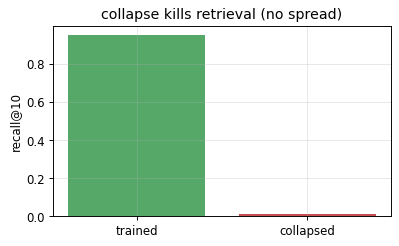

In [11]:
with torch.no_grad():
    good = (Qte @ Ite.T).numpy()                          # (raw) reasonable spread
# collapsed: push all vectors to almost one direction
v = rng.normal(0, 1, D_raw)
Qc = torch.tensor((0.02*Qte.numpy() + v), dtype=torch.float32)
Ic = torch.tensor((0.02*Ite.numpy() + v), dtype=torch.float32)
collapsed = (Qc @ Ic.T).numpy()
print(f"recall@10  trained encoder : {recall_at_k(S_easy,10):.2f}")
print(f"recall@10  collapsed space : {recall_at_k(collapsed,10):.2f}   <- can't separate anything")
plt.figure(figsize=(4.8,3)); plt.bar(["trained","collapsed"], [recall_at_k(S_easy,10), recall_at_k(collapsed,10)], color=[GREEN, RED])
plt.ylabel("recall@10"); plt.title("collapse kills retrieval (no spread)"); plt.show()

---
# Part B · Hard negatives & fine-tuning

## Step 6 · Triplet loss — a margin between positive and negative

An alternative to the softmax: a **triplet** (anchor query `q`, positive `p`, negative `n`)
with a **margin** `m`. Loss is zero **only** when the positive beats the negative by at least
`m`:
$$\mathcal{L}=\max(0,\; m + s(q,n) - s(q,p))$$

s(q,p)=3.0, s(q,n)=2.8, margin 0.5 -> 0.3  (still work to do)
s(q,p)=3.0, s(q,n)=0.2, margin 0.5 -> 0.0  (easy neg -> 0 loss, teaches little)


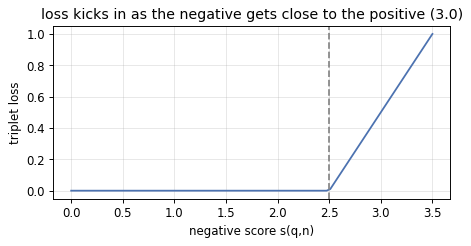

In [14]:
def triplet(s_qp, s_qn, m=0.5): return max(0.0, m + s_qn - s_qp)
print("s(q,p)=3.0, s(q,n)=2.8, margin 0.5 ->", round(triplet(3.0, 2.8), 2), " (still work to do)")
print("s(q,p)=3.0, s(q,n)=0.2, margin 0.5 ->", round(triplet(3.0, 0.2), 2), " (easy neg -> 0 loss, teaches little)")
sn = np.linspace(0, 3.5, 100)
plt.figure(figsize=(5.5,3)); plt.plot(sn, [triplet(3.0, x) for x in sn], color=BLUE)
plt.axvline(2.5, color=GRAY, ls="--"); plt.xlabel("negative score s(q,n)"); plt.ylabel("triplet loss")
plt.title("loss kicks in as the negative gets close to the positive (3.0)"); plt.show()

## Step 7 · Why hard negatives raise the gradient

In the softmax, a negative with a **high score** contributes a large term to the denominator,
**stealing probability** from the positive and keeping the loss (and gradient) high. Easy
negatives contribute almost nothing. Lesson example: positive 3.0, easy 0.2, **hard 2.8**.

positive probability WITH hard negative : 0.53 -> loss 0.63
positive probability WITHOUT it          : 0.94 -> loss 0.06
that gap (0.53 vs 0.94) is the training signal a hard negative provides.


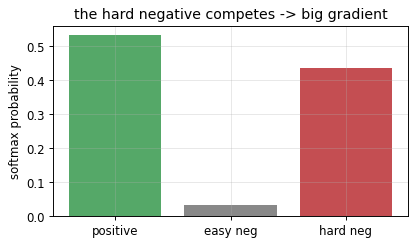

In [16]:
def softmax(x): x = x - x.max(); return np.exp(x)/np.exp(x).sum()
with_hard    = softmax(np.array([3.0, 0.2, 2.8]))
without_hard = softmax(np.array([3.0, 0.2]))
print("positive probability WITH hard negative :", round(with_hard[0], 2), "-> loss", round(-np.log(with_hard[0]),2))
print("positive probability WITHOUT it          :", round(without_hard[0], 2), "-> loss", round(-np.log(without_hard[0]),2))
plt.figure(figsize=(5,3)); plt.bar(["positive","easy neg","hard neg"], with_hard, color=[GREEN, GRAY, RED])
plt.ylabel("softmax probability"); plt.title("the hard negative competes -> big gradient"); plt.show()
print("that gap (0.53 vs 0.94) is the training signal a hard negative provides.")

## Step 8 · Mining hard negatives improves fine-grained recall

Random/in-batch negatives are usually **easy** (different topic) — they teach broad separation
but leave the model fuzzy **within** a topic. **Mine hard negatives** (same-topic, not the
positive) and add them to training: the model is forced to separate look-alikes, so
**fine-grained recall (recall@1) rises.**

                  recall@1  recall@5  recall@10
  easy negs only      0.43      0.84       0.95
     + hard negs      0.55      0.92       0.98
biggest gain is at recall@1 (the hardest, most fine-grained rank).


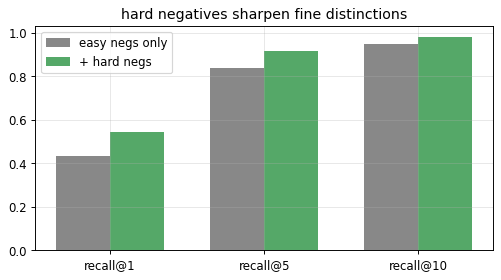

In [18]:
S_easy = train_infonce(use_hard=False)
S_hard = train_infonce(use_hard=True)
print(f"{'':>16}{'recall@1':>10}{'recall@5':>10}{'recall@10':>11}")
print(f"{'easy negs only':>16}{recall_at_k(S_easy,1):>10.2f}{recall_at_k(S_easy,5):>10.2f}{recall_at_k(S_easy,10):>11.2f}")
print(f"{'+ hard negs':>16}{recall_at_k(S_hard,1):>10.2f}{recall_at_k(S_hard,5):>10.2f}{recall_at_k(S_hard,10):>11.2f}")
ks = [1,5,10]
xb = np.arange(len(ks)); w = 0.35
plt.figure(figsize=(6,3.4))
plt.bar(xb-w/2, [recall_at_k(S_easy,k) for k in ks], w, color=GRAY, label="easy negs only")
plt.bar(xb+w/2, [recall_at_k(S_hard,k) for k in ks], w, color=GREEN, label="+ hard negs")
plt.xticks(xb, [f"recall@{k}" for k in ks]); plt.legend(); plt.title("hard negatives sharpen fine distinctions"); plt.show()
print("biggest gain is at recall@1 (the hardest, most fine-grained rank).")

## Step 9 · The catch — false negatives

A mined "hard negative" must **actually be negative**. Two valid creators for one brief look
like a hard pair; treating one as a negative teaches the model to **separate valid matches** —
damaging the encoder. So mine hard negatives, then **filter** likely false negatives (labels,
business rules, a cross-encoder), and validate false-negative-heavy slices.

In [20]:
miners = pd.DataFrame({
    "miner": ["BM25 (lexical)", "current model", "other retrieval model", "cross-encoder", "human/model filter"],
    "finds": ["same words, wrong meaning", "close in vector space, wrong attribute",
              "audience overlap, wrong content", "text matches but a rule forbids it", "removes accepted alternates"],
})
print(miners.to_string(index=False))
print("\ngood batch = easy negs (stability) + filtered hard negs (discrimination).")
print("bad batch  = treat every unclicked plausible item as negative -> false negatives.")

                miner                                  finds
       BM25 (lexical)              same words, wrong meaning
        current model close in vector space, wrong attribute
other retrieval model        audience overlap, wrong content
        cross-encoder     text matches but a rule forbids it
   human/model filter            removes accepted alternates

good batch = easy negs (stability) + filtered hard negs (discrimination).
bad batch  = treat every unclicked plausible item as negative -> false negatives.


---
## Recap — the M14 toolkit

**Encoders & the loss (Part A).** A **dual encoder** embeds query and item separately (score =
dot) so vectors can be **precomputed** for retrieval; a **cross-encoder** reads the pair
jointly — **more accurate but O(pairs)**, so it's for **reranking**. Contrastive **InfoNCE**
makes the positive win a softmax over negatives; **temperature τ** controls sharpness (low τ →
hard negatives get a bigger gradient). A **collapsed** space (no spread) can't separate
anything — you need **alignment + uniformity** (M11).

**Hard negatives (Part B).** **Triplet loss** enforces a margin between one positive and one
negative; **in-batch contrastive** uses many negatives at once. A **hard negative** (plausible
but wrong) competes with the positive in the softmax, so it **raises the gradient** and teaches
fine distinctions — **mining** them measurably improves fine-grained recall. But a **false
negative** (a valid match mislabeled) damages the encoder, so **filter** mined negatives and
validate slices.

**Where this connects:** M14 is *how* the encoders behind M11 embeddings and M12/M13 retrieval
are trained. Its in-batch softmax + logQ echo M10–M12; its hard-negative discipline is what
makes the retrieved candidate sets good enough for the downstream ranker.